In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))


['Untitled spreadsheet.gsheet', 'reddy 143.xlsx', 'reddy 143.gsheet', 'Colab Notebooks', 'TOC.IEEE FORMAT.docx', 'TOC.PPT[1]^^.ppt (1).pptx', 'TOC.PPT[1]^^.ppt (3) (1).pptx', 'TOC.PPT[1]^^.ppt (3).pptx', '221FA04710.pdf', '221FA04710.zip', '221fa04525.zip', 'nptl.pdf', 'dmt-ieee.docx', 'B-06_DMT_PPT.docx[1].pptx', '221FA04710,sec-i p (1).pdf', '221FA04710,sec-i p.pdf', '221FA04710,sec-i netwrok essential.pdf', 'SE_M1_Batch-06_PPT.pptx', 'pdc batch-6 ieee m1.pdf', 'pdc_batch-6 (1).pptx', 'InteractiveSheet_2025-03-03_03_52_41.gsheet', '241FA04D70.pptx', '241FA04D70.docx', 'InteractiveSheet_2025-03-21_13_42_42.gsheet', 'Handwriiten_document.zip', '221FA04710-Anki Reddy.pdf', 'IDP.zip', 'IDP Report_B6_3I.pdf', 'VID-20250523-WA0006 (1).mp4', 'VID-20250523-WA0006.mp4', "I am sharing 'experiment 3.pdf' with you from WPS Office", "I am sharing 'experiment 4.pdf' with you from WPS Office", 'Anki FC.pdf', 'give it in a tabluer format (1).gsheet', 'i want title,year of published ,accuracy in perc

In [ ]:
import zipfile
import os

ZIP_PATH = "/content/drive/MyDrive/datasets.zip"
EXTRACT_PATH = "/content/data"

os.makedirs(EXTRACT_PATH, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_PATH)

print("Dataset extracted successfully!")


Dataset extracted successfully!


In [ ]:
import os

BASE_DIR = "/content/data/datasets"

valid_folders = []

for folder in os.listdir(BASE_DIR):
    folder_path = os.path.join(BASE_DIR, folder)
    if os.path.isdir(folder_path) and len(os.listdir(folder_path)) > 0:
        valid_folders.append(folder)
    else:
        print(f"Skipping empty folder: {folder}")

print("Using folders:", valid_folders)


Skipping empty folder: cbis
Using folders: ['mias', 'inbreast', 'VinDr']


In [ ]:
import shutil

FINAL_DATASET = "/content/final_dataset"
benign_path = os.path.join(FINAL_DATASET, "benign")
malignant_path = os.path.join(FINAL_DATASET, "malignant")

os.makedirs(benign_path, exist_ok=True)
os.makedirs(malignant_path, exist_ok=True)

def copy_images(src_folder):
    for root, _, files in os.walk(src_folder):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                label = "malignant" if "mal" in root.lower() else "benign"
                dest = malignant_path if label == "malignant" else benign_path
                shutil.copy(os.path.join(root, file), dest)

for folder in valid_folders:
    copy_images(os.path.join(BASE_DIR, folder))

print("Images organized into benign / malignant")


Images organized into benign / malignant


In [ ]:
import tensorflow as tf

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)


In [ ]:
IMG_SIZE = (160, 160)   # reduced
BATCH_SIZE = 8          # reduced

train_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

train_ds = train_ds.shuffle(500).prefetch(1)
val_ds = val_ds.prefetch(1)


Found 20768 files belonging to 2 classes.
Using 16615 files for training.
Found 20768 files belonging to 2 classes.
Using 4153 files for validation.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05)
])


In [ ]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(160, 160, 3)
)

base_model.trainable = False


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 5, 5, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.CSVLogger('/content/training_log.csv'),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
]


In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 348s 138ms/step - accuracy: 0.9850 - loss: 0.0970 - val_accuracy: 0.9892 - val_loss: 0.0552
Epoch 2/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 305s 125ms/step - accuracy: 0.9900 - loss: 0.0537 - val_accuracy: 0.9892 - val_loss: 0.0481
Epoch 3/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 292s 111ms/step - accuracy: 0.9889 - loss: 0.0480 - val_accuracy: 0.9889 - val_loss: 0.0400
Epoch 4/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 350s 125ms/step - accuracy: 0.9906 - loss: 0.0365 - val_accuracy: 0.9887 - val_loss: 0.0358
Epoch 5/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 275s 111ms/step - accuracy: 0.9879 - loss: 0.0386 - val_accuracy: 0.9880 - val_loss: 0.0312
Epoch 6/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 274s 110ms/step - accuracy: 0.9886 - loss: 0.0314 - val_accuracy: 0.9884 - val_loss: 0.0293
Epoch 7/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 273s 110ms/step - accuracy: 0.9883 - loss: 0.0319 - val_accuracy: 0.9884 - val_loss: 0.0290
Epoch 8/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 276s 111ms/step - ac

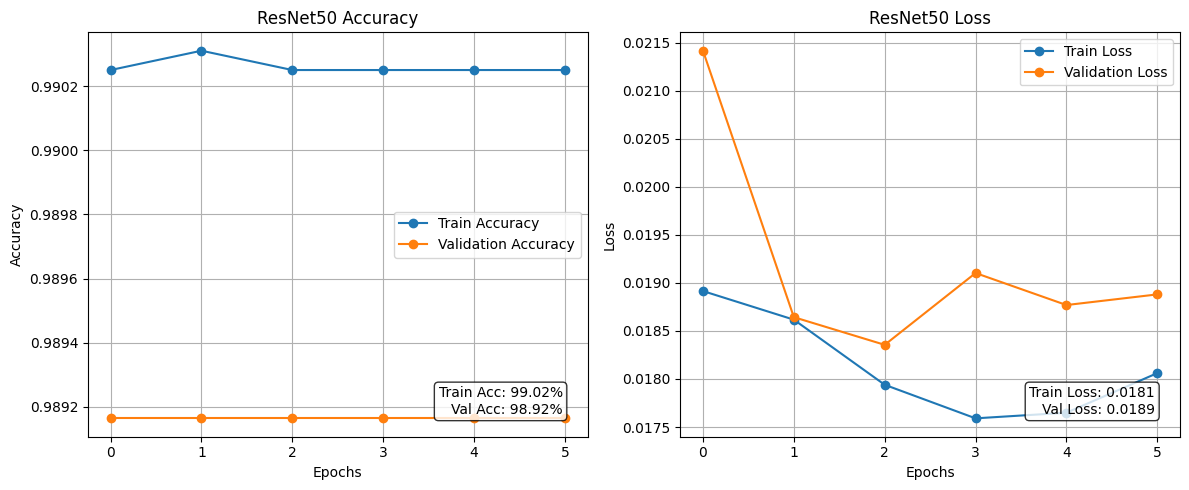

In [ ]:
import matplotlib.pyplot as plt

# Extract final values from ResNet50 history
train_acc = history.history['accuracy'][-1] * 100
val_acc = history.history['val_accuracy'][-1] * 100
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.legend()
plt.title("ResNet50 Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)

# Accuracy text box
plt.text(
    0.95, 0.05,
    f"Train Acc: {train_acc:.2f}%\nVal Acc: {val_acc:.2f}%",
    transform=plt.gca().transAxes,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

# Loss plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.legend()
plt.title("ResNet50 Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)

# Loss text box
plt.text(
    0.95, 0.05,
    f"Train Loss: {train_loss:.4f}\nVal Loss: {val_loss:.4f}",
    transform=plt.gca().transAxes,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.tight_layout()
plt.show()


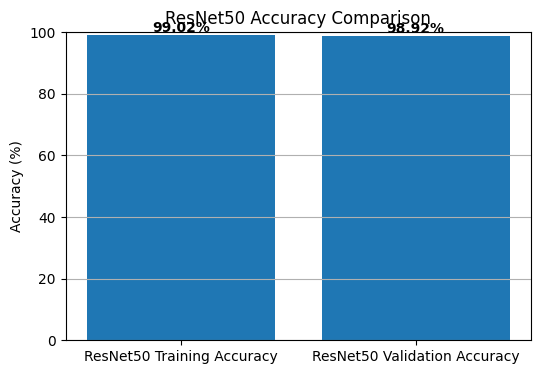

In [ ]:
import matplotlib.pyplot as plt

# Final accuracy values from ResNet50 history
train_acc = history.history['accuracy'][-1] * 100
val_acc = history.history['val_accuracy'][-1] * 100

# Bar graph data
labels = ['ResNet50 Training Accuracy', 'ResNet50 Validation Accuracy']
accuracy_values = [train_acc, val_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracy_values)

plt.title('ResNet50 Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Show accuracy values on bars
for i, value in enumerate(accuracy_values):
    plt.text(i, value + 1, f"{value:.2f}%", ha='center', fontweight='bold')

plt.grid(axis='y')
plt.show()


In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred = model.predict(val_ds)
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))


520/520 ━━━━━━━━━━━━━━━━━━━━ 41s 78ms/step
[[4108    0]
 [  45    0]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      4108
           1       0.00      0.00      0.00        45

    accuracy                           0.99      4153
   macro avg       0.49      0.50      0.50      4153
weighted avg       0.98      0.99      0.98      4153



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [ ]:
IMG_SIZE = (160, 160)
BATCH_SIZE = 8

train_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    FINAL_DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

train_ds = train_ds.shuffle(500).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)


Found 20768 files belonging to 2 classes.
Using 16615 files for training.
Found 20768 files belonging to 2 classes.
Using 4153 files for validation.


In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
])


In [ ]:
cnn_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255, input_shape=(160, 160, 3)),
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(1, activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 158, 158, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 79, 79, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 77, 77, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 38, 38, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 36, 36, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.CSVLogger('/content/cnn_training_log.csv')
]


In [ ]:
history_cnn = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 249s 97ms/step - accuracy: 0.9889 - loss: 0.0406 - val_accuracy: 0.9892 - val_loss: 0.0203
Epoch 2/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 246s 97ms/step - accuracy: 0.9897 - loss: 0.0184 - val_accuracy: 0.9892 - val_loss: 0.0185
Epoch 3/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 285s 116ms/step - accuracy: 0.9902 - loss: 0.0177 - val_accuracy: 0.9892 - val_loss: 0.0186
Epoch 4/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 285s 116ms/step - accuracy: 0.9896 - loss: 0.0180 - val_accuracy: 0.9892 - val_loss: 0.0190
Epoch 5/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 286s 116ms/step - accuracy: 0.9888 - loss: 0.0208 - val_accuracy: 0.9892 - val_loss: 0.0198


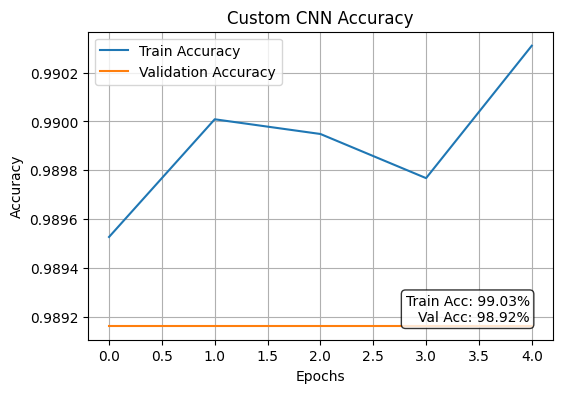

In [ ]:
train_acc = history_cnn.history['accuracy'][-1] * 100
val_acc = history_cnn.history['val_accuracy'][-1] * 100

plt.figure(figsize=(6,4))
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title("Custom CNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.text(
    0.95, 0.05,
    f"Train Acc: {train_acc:.2f}%\nVal Acc: {val_acc:.2f}%",
    transform=plt.gca().transAxes,
    ha='right',
    va='bottom',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.8)
)

plt.show()


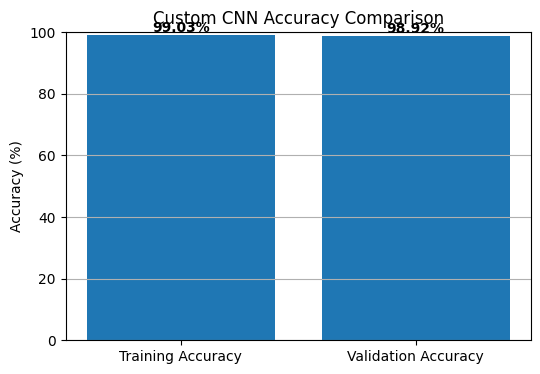

In [ ]:
import matplotlib.pyplot as plt

# Final accuracy values from CNN history
train_acc = history_cnn.history['accuracy'][-1] * 100
val_acc = history_cnn.history['val_accuracy'][-1] * 100

# Data for bar graph
labels = ['Training Accuracy', 'Validation Accuracy']
accuracy_values = [train_acc, val_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracy_values)

plt.title('Custom CNN Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Display values on bars
for i, v in enumerate(accuracy_values):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontweight='bold')

plt.grid(axis='y')
plt.show()


1️⃣ VGG16


In [ ]:
base_vgg = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(160,160,3)
)
base_vgg.trainable = False

vgg16_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_vgg,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

vgg16_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_vgg16 = vgg16_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)


Epoch 1/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 273s 108ms/step - accuracy: 0.9860 - loss: 0.0725 - val_accuracy: 0.9892 - val_loss: 0.0221
Epoch 2/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 261s 105ms/step - accuracy: 0.9904 - loss: 0.0230 - val_accuracy: 0.9894 - val_loss: 0.0192
Epoch 3/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 262s 105ms/step - accuracy: 0.9876 - loss: 0.0216 - val_accuracy: 0.9894 - val_loss: 0.0190
Epoch 4/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 276s 112ms/step - accuracy: 0.9892 - loss: 0.0204 - val_accuracy: 0.9882 - val_loss: 0.0183
Epoch 5/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 275s 109ms/step - accuracy: 0.9892 - loss: 0.0183 - val_accuracy: 0.9894 - val_loss: 0.0185
Epoch 6/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 275s 110ms/step - accuracy: 0.9881 - loss: 0.0199 - val_accuracy: 0.9894 - val_loss: 0.0181
Epoch 7/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 286s 114ms/step - accuracy: 0.9883 - loss: 0.0184 - val_accuracy: 0.9896 - val_loss: 0.0180
Epoch 8/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 310s 126ms/step - ac

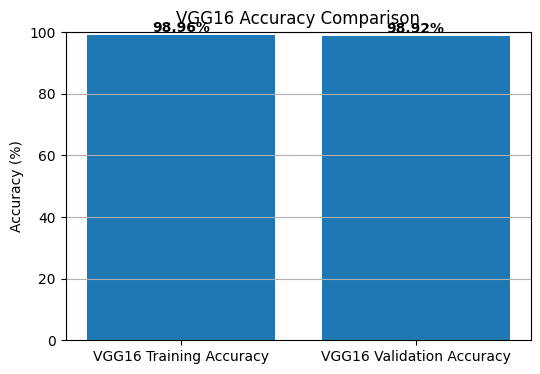

In [ ]:
import matplotlib.pyplot as plt

# Extract final accuracy values
train_acc = history_vgg16.history['accuracy'][-1] * 100
val_acc = history_vgg16.history['val_accuracy'][-1] * 100

# Data for bar graph
labels = ['VGG16 Training Accuracy', 'VGG16 Validation Accuracy']
accuracy_values = [train_acc, val_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracy_values)

plt.title('VGG16 Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Show values on bars
for i, acc in enumerate(accuracy_values):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center', fontweight='bold')

plt.grid(axis='y')
plt.show()


2️⃣ MobileNetV2 (Lightweight network)


In [ ]:
base_mobilenet = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(160,160,3)
)
base_mobilenet.trainable = False

mobilenet_model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),
    base_mobilenet,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 830s 357ms/step - accuracy: 0.9782 - loss: 0.0493 - val_accuracy: 0.9856 - val_loss: 0.0226
Epoch 2/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 862s 382ms/step - accuracy: 0.9868 - loss: 0.0228 - val_accuracy: 0.9836 - val_loss: 0.0247
Epoch 3/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 815s 359ms/step - accuracy: 0.9884 - loss: 0.0226 - val_accuracy: 0.9836 - val_loss: 0.0276
Epoch 4/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 862s 357ms/step - accuracy: 0.9885 - loss: 0.0222 - val_accuracy: 0.9824 - val_loss: 0.0262
Epoch 5/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 900s 377ms/step - accuracy: 0.9885 - loss: 0.0217 - val_accuracy: 0.9829 - val_loss: 0.0277
Epoch 6/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 856s 374ms/step - accuracy: 0.9875 - loss: 0.0225 - val_accuracy: 0.9815 - val_loss: 0.0304
Epoch 7/10
2077/2077 ━━━━━━━━━━━━━━━━━━━━ 837s 369ms/step - accuracy: 0.9878 - loss: 0.0238 - val_accuracy: 0.9892 - val_loss: 0.0444
Epoch 8/10
20

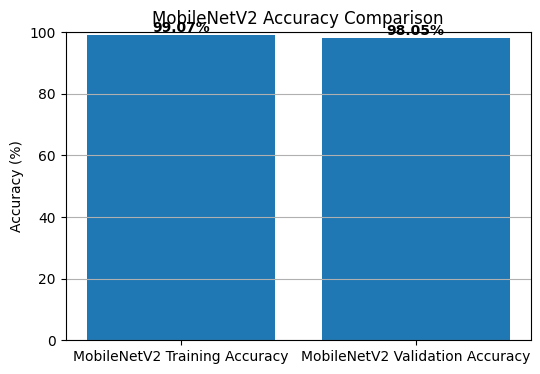

In [ ]:
import matplotlib.pyplot as plt

# Extract final accuracy values
train_acc = history_mobilenet.history['accuracy'][-1] * 100
val_acc = history_mobilenet.history['val_accuracy'][-1] * 100

# Data for bar graph
labels = ['MobileNetV2 Training Accuracy', 'MobileNetV2 Validation Accuracy']
accuracy_values = [train_acc, val_acc]

plt.figure(figsize=(6,4))
plt.bar(labels, accuracy_values)

plt.title('MobileNetV2 Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)

# Display accuracy values on bars
for i, acc in enumerate(accuracy_values):
    plt.text(i, acc + 1, f"{acc:.2f}%", ha='center', fontweight='bold')

plt.grid(axis='y')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 846ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 543ms/step


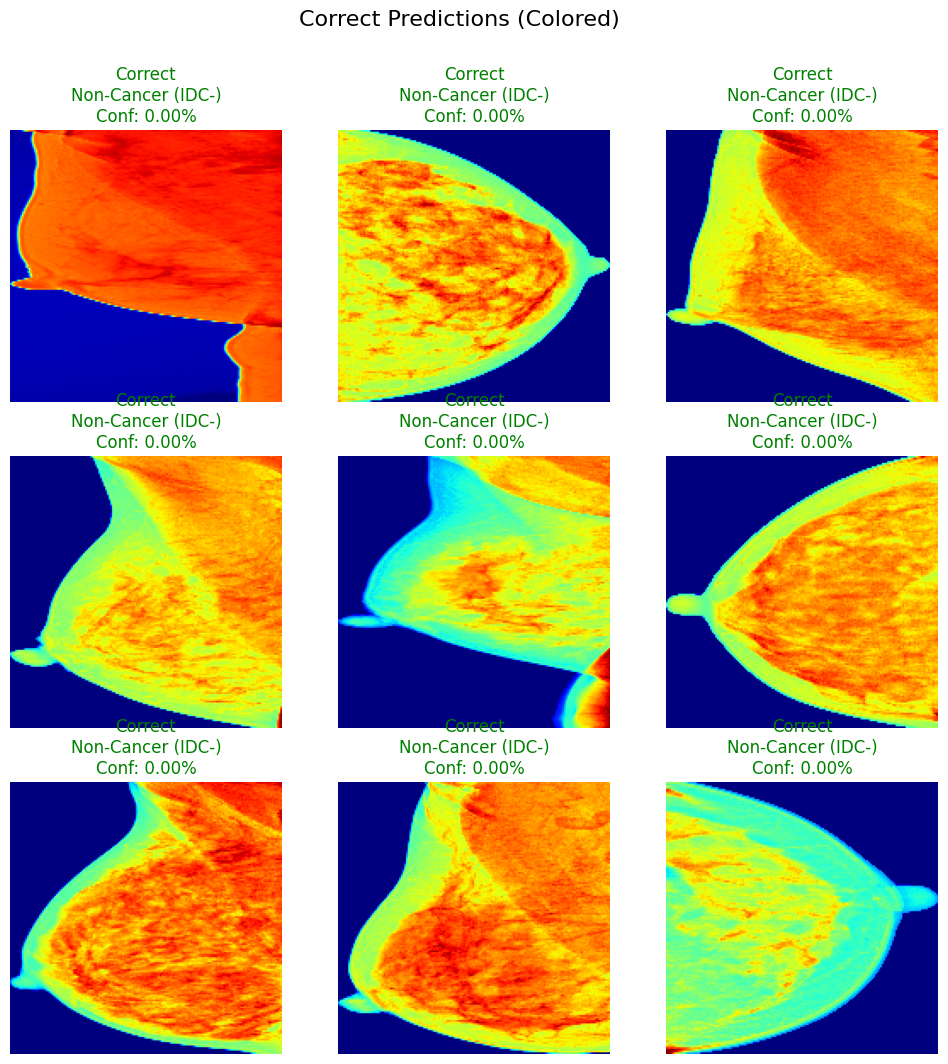

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["Non-Cancer (IDC-)", "Cancer (IDC+)"]

model = mobilenet_model   # or vgg16_model

plt.figure(figsize=(12,12))
count = 0

for images, labels in val_ds:
    probs = model.predict(images).reshape(-1)
    preds = (probs > 0.5).astype(int)

    for i in range(images.shape[0]):
        if labels[i] == preds[i] and count < 9:
            ax = plt.subplot(3,3,count+1)

            # 🔥 Colored display (pseudo-color)
            plt.imshow(images[i].numpy()[:,:,0], cmap='jet')
            plt.axis("off")

            plt.title(
                f"Correct\n{class_names[int(preds[i])]}\nConf: {probs[i]*100:.2f}%",
                color="green"
            )

            count += 1

    if count >= 9:
        break

plt.suptitle("Correct Predictions (Colored)", fontsize=16)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 708ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 517ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 774ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 324ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 366ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 413ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

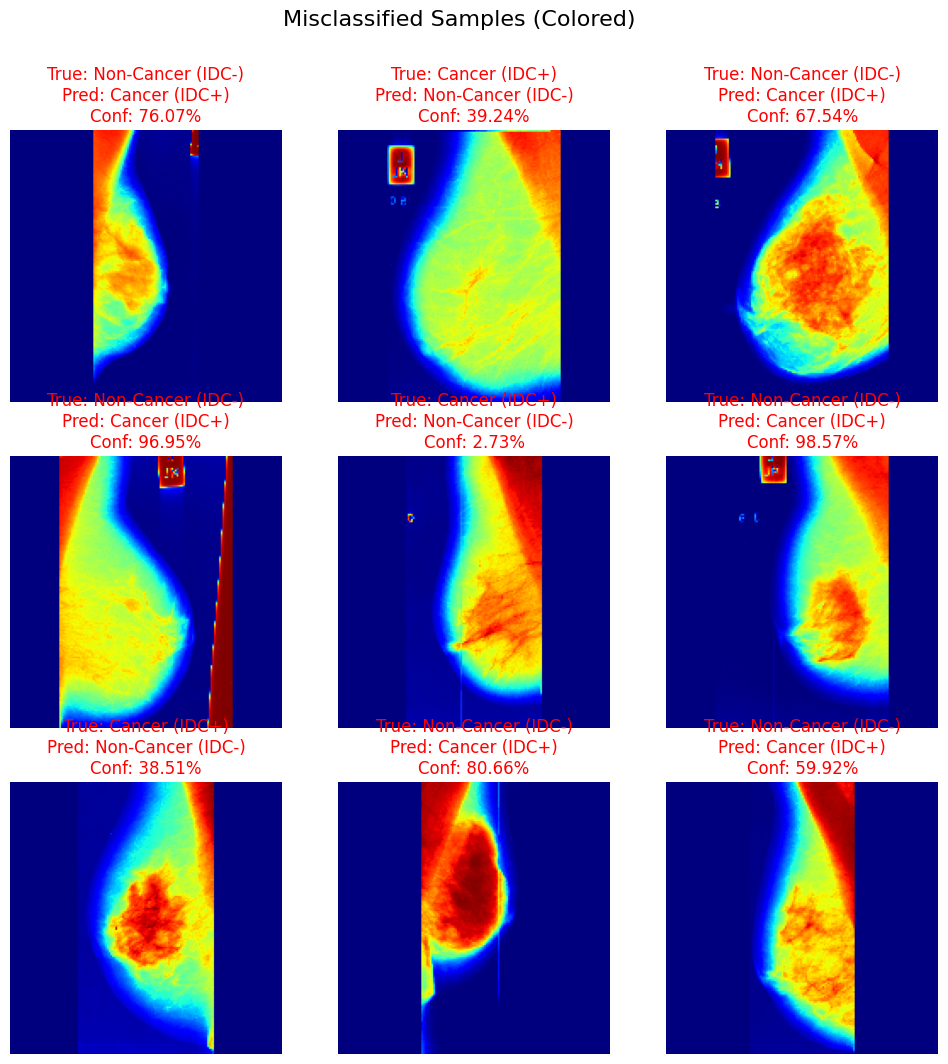

In [ ]:
plt.figure(figsize=(12,12))
count = 0

for images, labels in val_ds:
    probs = model.predict(images).reshape(-1)
    preds = (probs > 0.5).astype(int)

    for i in range(images.shape[0]):
        if labels[i] != preds[i] and count < 9:
            ax = plt.subplot(3,3,count+1)

            # 🔥 Colored display (pseudo-color)
            plt.imshow(images[i].numpy()[:,:,0], cmap='jet')
            plt.axis("off")

            plt.title(
                f"True: {class_names[int(labels[i])]}\n"
                f"Pred: {class_names[int(preds[i])]}\n"
                f"Conf: {probs[i]*100:.2f}%",
                color="red"
            )

            count += 1

    if count >= 9:
        break

plt.suptitle("Misclassified Samples (Colored)", fontsize=16)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


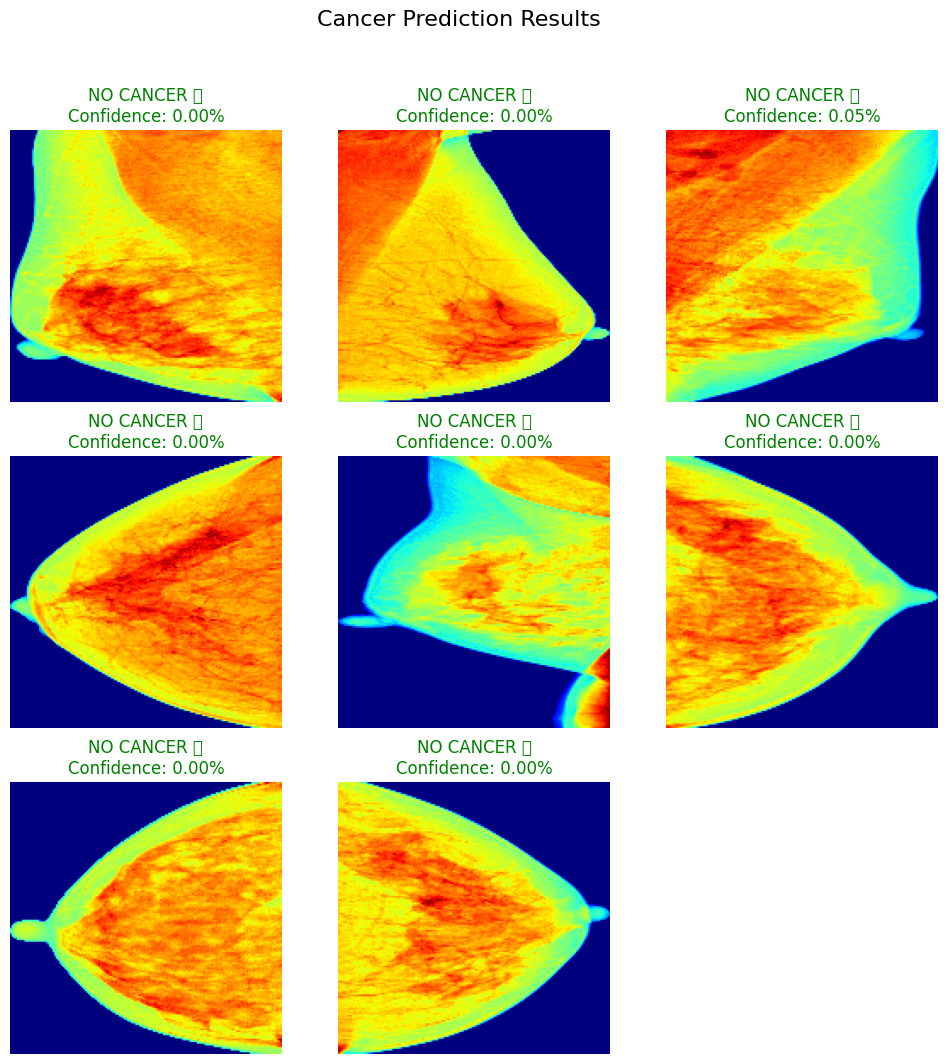

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

class_names = ["Non-Cancer (IDC-)", "Cancer (IDC+)"]

model = mobilenet_model   # or vgg16_model

plt.figure(figsize=(12,12))

for images, labels in val_ds.take(1):
    probs = model.predict(images).reshape(-1)
    preds = (probs > 0.5).astype(int)

    num_images = min(9, images.shape[0])

    for i in range(num_images):
        ax = plt.subplot(3,3,i+1)

        # Display image (colored pseudo-color)
        plt.imshow(images[i].numpy()[:,:,0], cmap='jet')
        plt.axis("off")

        # Decision
        decision = "CANCER DETECTED ✅" if preds[i] == 1 else "NO CANCER ❌"

        plt.title(
            f"{decision}\n"
            f"Confidence: {probs[i]*100:.2f}%",
            color="red" if preds[i] == 1 else "green"
        )

plt.suptitle("Cancer Prediction Results", fontsize=16)
plt.show()


In [ ]:
for images, labels in val_ds.take(1):
    prob = model.predict(images)[0][0]
    if prob > 0.5:
        print(f"Cancer Detected (Confidence: {prob*100:.2f}%)")
    else:
        print(f"No Cancer Detected (Confidence: {(1-prob)*100:.2f}%)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
No Cancer Detected (Confidence: 100.00%)
